In [1]:
import numpy as np
from scipy import special as sp
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import os
import json
from scipy import ndimage

In [2]:
root_dir = '../simulations'
params_path = os.path.join(root_dir, 'map_params.json')
params = json.load(open(params_path))

# Read map parameters.
eps = params['eps']
alpha = params['alpha']
ps = {1: params['p1'], 2: params['p2']} # misclassification rates
Ns = {1: params['N1dot']*params['px_per_km2'], 2: params['N2dot']*params['px_per_km2']} # mapped areas (pixels)

In [3]:
cyan, red, dark = '#00eeee', '#ff0000', '#555555'
gray = [0.5, 0.5, 0.5, 1.0]
dark = '#222222'

sns.set_style('darkgrid')

# 1. $\text{Pr}(x=0)$

### Setup

In [4]:
max_p = .02
max_n = 1000

n_ps = 200
n_ns = 200
n_ylabels = 20
n_xlabels = 20
n_contours = 10
annot = False

all_ps = np.linspace(0, max_p, num=n_ps+1)
all_ns = np.linspace(0, max_n, num=n_ns+1)[1:].astype(int)

In [5]:
P_COL = 'population proportion'
N_COL = 'sample size'
PROB_COL = 'probability of zero false negatives'

### Calculate $\text{Pr}(x=0)$ for population $N$

In [6]:
N = int(Ns[2]) # common class size (pixels)

probs = []
for p in all_ps:
    X = int((1-p)*N)
    probs.append([sp.comb(X, n, exact=True) / sp.comb(N, n, exact=True) for n in all_ns])

### Plot

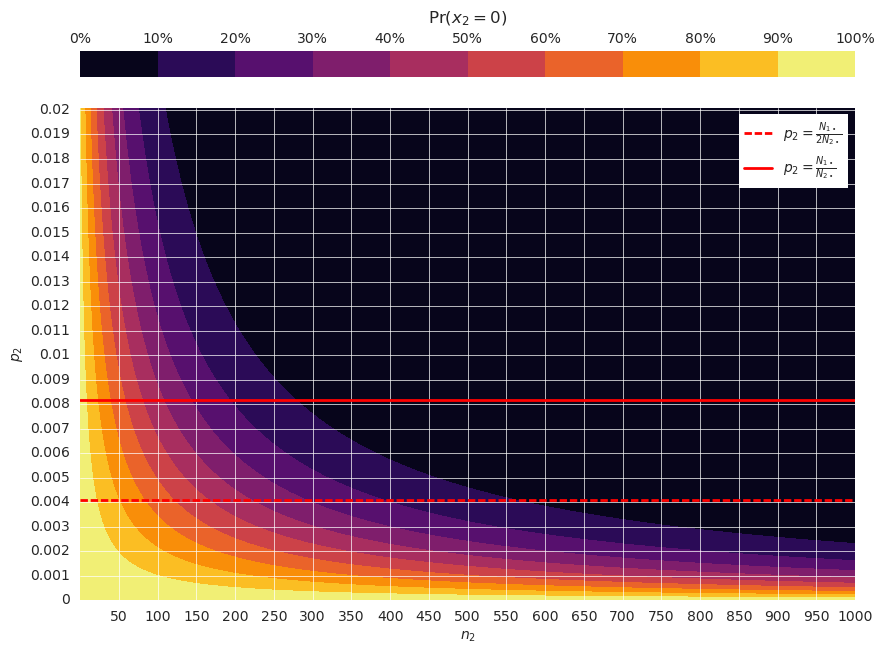

In [8]:
df = pd.DataFrame(probs)
df.columns = all_ns
df.set_index(all_ps)

make_labels = np.vectorize(lambda x: x[0] if x.endswith('.0') else x[1:])
prob_labels = make_labels(np.round(probs, 2).astype(str)) if annot else False

fig, ax = plt.subplots(figsize=(10,8))

# Contour
smooth_scale = 1
z = ndimage.zoom(df.to_numpy(), smooth_scale)
cntrs = ax.contourf(np.linspace(0, len(df.columns), len(df.columns) * smooth_scale),
                   np.linspace(0, len(df.index), len(df.index) * smooth_scale),
                   z, levels=np.linspace(0, 1, n_contours+1), cmap='inferno')

# Heatmap
ax = sns.heatmap(df, annot=prob_labels, linewidths=0, fmt = '', vmin=0, vmax=1, ax=ax, alpha=0,
                 cbar=False)
x_ticks = np.arange(n_ns)[n_ns // n_xlabels - 1::n_ns // n_xlabels] + 1
ax.set_xticks(x_ticks)
ax.set_xticklabels(all_ns[n_ns // n_xlabels - 1::n_ns // n_xlabels], rotation=0)
if n_xlabels < n_ns:
    ax.xaxis.set_ticks_position('none')
for x in x_ticks:
    ax.axvline(x, color='w', lw=.5)

y_ticks = np.arange(n_ps+1)[::n_ps // n_ylabels]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{p:.3g}' for p in np.linspace(0, max_p, num=n_ps+1)[y_ticks]], rotation=0)
if n_ylabels < n_ps:
    ax.yaxis.set_ticks_position('none')
for y in y_ticks:
    ax.axhline(y, color='w', lw=.5)

# Horizontal lines
ax.axhline(.5*Ns[1]/Ns[2]*n_ps/max_p, color='r', linestyle='dashed', lw=2,
           dashes=(2.67, 1), label=r'$p_2=\frac{N_{1\bullet}}{2N_{2\bullet}}$')
ax.axhline(Ns[1]/Ns[2]*n_ps/max_p, color='r', linestyle='solid', lw=2, label=r'$p_2=\frac{N_{1\bullet}}{N_{2\bullet}}$')

legend = ax.legend(fancybox=False, loc='upper right', shadow=False, facecolor='w', framealpha=1)
legend.get_frame().set_linewidth(0)

ax.set_xlabel('$n_2$')
ax.set_ylabel('$p_2$')

cbar = plt.colorbar(cntrs, ax=ax, orientation='horizontal', location='top',
                    aspect=30)
cbar.set_ticks(np.linspace(0, 1, n_contours+1))
cbar.set_ticklabels(make_labels(np.round(np.linspace(0, 1, n_contours+1), 2).astype(str)))
cbar.set_ticklabels([f'{prob:.0%}' for prob in np.linspace(0, 1, n_contours+1)])
prob_labels = [f'{prob:.0%}' for prob in probs] if annot else False
cbar.ax.tick_params(length=0)
plt.setp(cbar.ax.spines.values(), visible=False) 
cbar.ax.set_title(r'$\mathrm{Pr}(x_2=0)$')

plt.gca().invert_yaxis()

plt.savefig(f'1_Pr(x=0).png', bbox_inches='tight', dpi=600)